Our expectation with the original LEMBAS is as follows:
1) It cannot handle multiple cell types
2) It cannot account for the dispersion within a cluster at single-cell resolution, and will output the centroid of a cluster instead.

Next, we want to see whether scLEMBAS can capture single-cell resolution data.

In [1]:
import os
from itertools import combinations

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from scipy.spatial.distance import cdist, pdist, squareform

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import patchworklib as pw

import sys

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import parse_network, io
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainCat, TrainSC
from scLEMBAS.plotting import plot_embedding
from scLEMBAS.preprocess import embed_tf_activity


<Figure size 100x100 with 0 Axes>

In [2]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888

device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')
if not os.path.isdir(models_path):
    os.mkdir(models_path)

In [3]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'processed', 'ID_tf_activity.h5ad'))

# Load and Parse Input Signaling Network

In [4]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [5]:
sn_ppis = parse_network.load_network('omnipath', organism = 'mouse', static = True)

sn_ppis = parse_network.correct_network(sn_ppis = sn_ppis,
                                        source_label = source_label, target_label = target_label,
                                        stimulation_label = stimulation_label, inhibition_label = inhibition_label)

sn_ppis = parse_network.extract_network(sn_ppis, curation_effort_thresh = 5, n_references_thresh = 3,
                                        resources = ['HuRI','IntAct','KEGG-MEDICUS','NetPath','Reactome_SignaLink3','SPIKE','SignaLink3','SIGNOR', 
                                                'Baccin2019', 'Ramilowski2015', 'Reactome_LRdb', 'UniProt_LRdb', 'CellChatDB', 'CellPhoneDB', 'connectomeDB2020', 'scConnect'], 
                                        source_label = source_label, target_label = target_label,
                                        drop_self = True, verbose = True)



The thresholds filtered 66381  of 75185 interactions
The resources filtered 1940  of 8804 interactions


Filter for nodes that fall in paths between ligands and receptors (fully connected network):

In [6]:
tf_labels = tf_adata.var.index.unique().tolist()

ligand_labels = tf_adata.obs['sample'].unique().tolist()
ligand_labels = [(l[0] + l[1:].lower()).replace('-', '') for l in ligand_labels] # mouse naming convention

# filter for paths b/w ligand and tf
fn_1, _ = parse_network.create_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'shortest')
fn_2, _ = parse_network.create_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'connected')
# of the methods to identify paths, retain the one that has the most interactions
if fn_1.shape[0] > fn_2.shape[0]:
    sn_ppis = fn_1
else:
    sn_ppis = fn_2

del fn_1, fn_2


100%|████████████████████████████████████| 8432/8432 [00:00<00:00, 18800.02it/s]


Finally, let's format the network as needed for input to building the model:

In [7]:
sn_ppis = parse_network.format_network(sn_ppis, weight_label, stimulation_label, inhibition_label) 
# sn_ppis.to_csv(os.path.join(data_path, 'processed', 'ID_input_network.csv'))

In [8]:
print('The signaling network contains {} interactions'.format(sn_ppis.shape[0]))
sn_ppis[[source_label, target_label, weight_label, stimulation_label, inhibition_label]].head()

The signaling network contains 4583 interactions


,source_genesymbol,target_genesymbol,mode_of_action,consensus_stimulation,consensus_inhibition
145,Mapk14,Mapkapk2,1.0,True,False
146,Mapkapk2,Mapk14,0.1,False,False
152,Epor,Jak2,0.1,False,False
153,Jak2,Epor,1.0,True,False
159,Numb,Notch1,-1.0,False,True


The interactions include the following input ligands:

In [9]:
all_nodes = sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()
input_ligands_available = sorted(set(ligand_labels).intersection(all_nodes))
print(*input_ligands_available, sep = ', ')

Egf, Gdnf, Hgf, Ifng, Il10, Il11, Il13, Il15, Il1a, Il1b, Il2, Il21, Il4, Il5, Il6, Il7, Il9, Lif, Osm, Tslp


# Explore performance on TF activity

In [10]:
group_label = 'TF_clusters' # ordered cateogry in obs

## Scenario 3:

In [11]:
model_no = 3

The simplest scenario is:
- 2 cell type
- 1 ligand
- Binary ligand exposure (0 or 1)
- Exposure leads to distinct clusters in TF activity space

For now, we simply use visualization to identify the most distinct clusters:

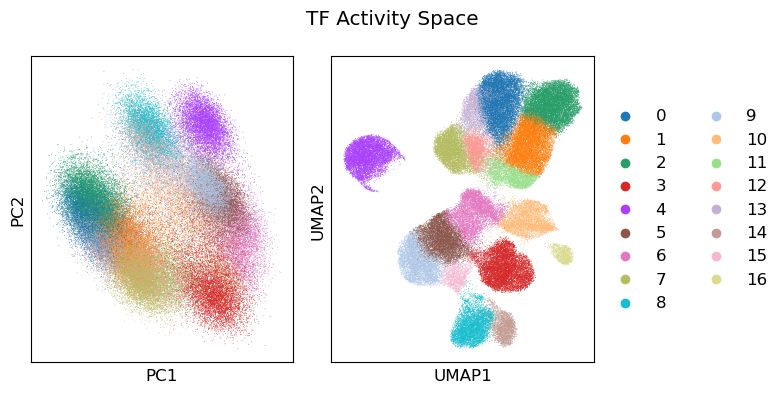

In [12]:
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(tf_adata, color='TF_clusters', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(tf_adata, color='TF_clusters', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('TF Activity Space')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()


Based on these results, we choose clusters 2, 3, 4, and 5:

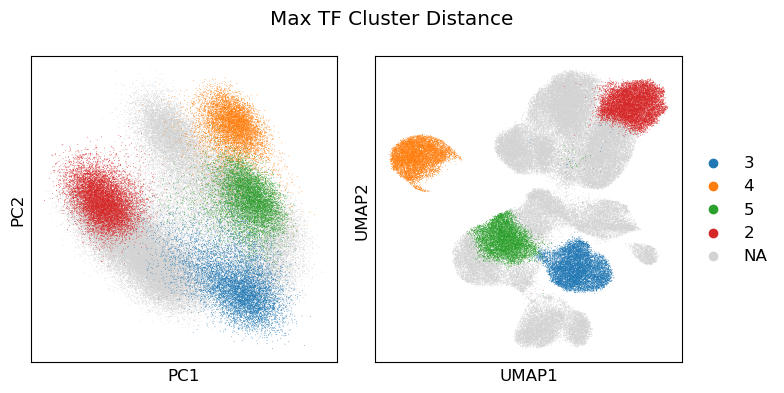

In [13]:
max_clusters = ['3', '4', '5', '2']
viz_adata = tf_adata.copy()
viz_adata.obs[group_label + '_color'] = pd.Categorical(viz_adata.obs[group_label], 
                                                       categories = max_clusters, 
                                                       ordered = True)
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(viz_adata, color=group_label + '_color', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(viz_adata, color=group_label + '_color', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('Max TF Cluster Distance')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()


Based on these results, let's say that cluster 9 is unstimulated, and cluster 15 is stimulated. 

In [14]:
max_clusters = ['3', '4', '5', '2']

In [15]:
np.random.seed(seed)
selected_ligand = np.random.choice(input_ligands_available, 1)[0]
print('The selected ligand is: ' + selected_ligand)

subset_tf = tf_adata[tf_adata.obs.TF_clusters.isin(max_clusters)]
subset_tf.obs.TF_clusters.value_counts()

The selected ligand is: Il5


TF_clusters
2    9687
3    8522
4    7336
5    6970
Name: count, dtype: int64

For now, for speed, let's subset so that there are a smaller number of "samples" per condition:

In [16]:
sample_size = int(2.5e3)

barcodes = []
for cluster_label in subset_tf.obs.TF_clusters.unique():
    bc = subset_tf.obs[subset_tf.obs.TF_clusters == cluster_label].index
    np.random.seed(seed)
    barcodes += list(np.random.choice(bc, sample_size, replace = False))
subset_tf = subset_tf[barcodes, :]
subset_tf.obs.TF_clusters.value_counts()

TF_clusters
2    2500
3    2500
4    2500
5    2500
Name: count, dtype: int64

Next, let's initialize the model. 

Let's say clusters 4 and 5 are unstimulated, and 3 and 2 are stimulated
We assign clusters 3 and 4 as cell Type A, and 5 and 2 as cell type B.

In [17]:
ligand_input = pd.DataFrame(subset_tf.obs.TF_clusters.map({'4': 0, '5': 0, '3': 1, '2': 1}))
ligand_input.columns = [selected_ligand]


covariates = pd.DataFrame(subset_tf.obs.TF_clusters.map({'3': 'A', '4': 'A',
                                                        '5': 'B', '2': 'B'}))
covariates.columns = ['celltype']


tf_output = pd.DataFrame(subset_tf.X, index = subset_tf.obs.index, columns = subset_tf.var.index)


In [18]:
subset_tf.obs = pd.concat([covariates, ligand_input, pd.DataFrame({'TF_clusters': subset_tf.obs.TF_clusters})], axis = 1)

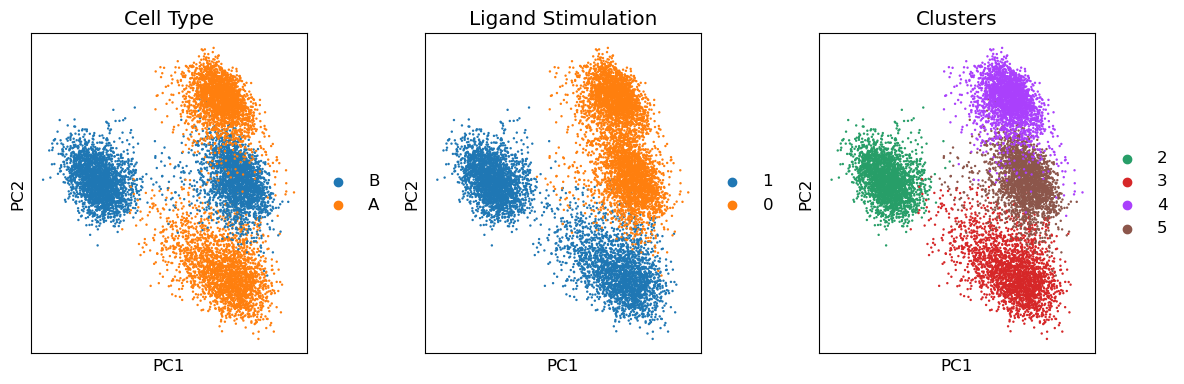

In [19]:
viz_adata = subset_tf.copy()
for col in viz_adata.obs.columns:
    viz_adata.obs[col] = pd.Categorical(viz_adata.obs[col],
                                        categories = viz_adata.obs[col].unique())


fig, ax = plt.subplots(ncols = 3, figsize = (12, 4))
sc.pl.pca(viz_adata, color='celltype', ax = ax[0], show = False)
ax[0].set_title('Cell Type')

sc.pl.pca(viz_adata, color=selected_ligand, ax = ax[1], show = False)
ax[1].set_title('Ligand Stimulation')

sc.pl.pca(viz_adata, color='TF_clusters', ax = ax[2], show = False)
ax[2].set_title('Clusters')


fig.tight_layout()
plt.show()


In [20]:
# linear scaling of inputs/outputs
projection_amplitude_in = 3
projection_amplitude_out = 1.2
# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 1} 
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.LeakyReLU,
              'vae_n_hidden_nodes': [1024, 768, 512], 
              'vae_var_min': 1e-4}
bionet_params = {**bionet_params, **vae_params}

# training parameters
me = 2000
lr_params = {'max_epochs': 2000, 'maximum_learning_rate': 2e-3, 'minimum_learning_rate': 2e-4,
                 'lr_restart_epoch': int(me/5), 'reset_optimizer_epoch': 200, 
                'lr_decay': 0.9, 'lr_restart_factor': 1, 'warmup_epochs': int(me/10)}

other_params = {'train_batch_size': 2056, 'test_batch_size': 512, 'validation_batch_size': 512, 
                    'network_noise_scale': 10, 'gradient_noise_scale': 1e-9}

regularization_params = {'input_lambda_L2': 1e-6, 'hidden_state_lambda_L2': 1e-6, 'bias_lambda_L2': 1e-6, 
                             'output_lambda_L2': 1e-6, 
                         'discriminator_lambda_L2': 1e-5,
                         'moa_lambda_L1': 0.1, #'ligand_lambda_L2': 1e-5, 
                         'uniform_lambda_L2': 1e-4,  
                         'uniform_max': (1/1.2), 
                         'spectral_loss_factor': 1e-5, 
                        'vae_lambda_l2': 1e-5, 
                        'vae_scaling_KL': 1e-2}
spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 50, 
                          'subset_n_spectral': 10}

training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}
target_spectral_radius = 0.8

discriminator_params = {'batch_momentum': 0.01,
 'layer_norm': False,
 'dropout_rate': 0.1,
 'activation_fn': nn.LeakyReLU,
 'n_hidden_nodes': [16, 16, 16],
 'maximum_learning_rate': 2e-3,
 'minimum_learning_rate':2e-4,
 'lr_restart_epoch': int(me/5),
 'reset_optimizer_epoch': 200,
 'lr_decay': 0.9,
 'lr_restart_factor': 1,
 'warmup_epochs': int(me/10),
 'optimizer': torch.optim.Adam,
 'discriminator_lambda_L2': 1e-05, 
                       'discriminator_penalty_weight': 1}


In [21]:
mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     expr = subset_tf.to_df(), 
                     covariates = subset_tf.obs,
                     categorical_covariate_keys = ['celltype'],
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)



In [22]:
# get pca on on selected features
subset_tf = subset_tf[:, mod.y_out.columns]
embed_tf_activity(subset_tf)

# Start dev

In [40]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainSC(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                  discriminator_params = discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': 0.8, 'test': 0.2, 'validation': None}, 
                   train_seed = seed, 
                   track_test = True,
                   track_validation = False)

In [41]:
trainer.hyper_params['max_epochs'] = 2
mod = trainer.train_model(verbose = True)

 50%|██████████████████████▌                      | 1/2 [00:06<00:06,  6.34s/it]

i=0, l(tr)=0.21816, l(te)=0.22548, s=0.26719, r=0.00020, v=0.00000


100%|█████████████████████████████████████████████| 2/2 [00:12<00:00,  6.34s/it]

Training ran in: 0 min 12.68 sec


In [44]:
trainer.stats['train']

,epoch,batch_index,learning_rate,discriminator_learning_rate,iter_time,spectral_radius,n_moa_violations,train_loss_total,train_loss_prediction,train_pearson,...,stability_reg_loss,uniform_reg_loss,input_param_reg_loss,sn_param_reg_loss,vae_param_reg_loss,kl_divergence,discriminator_loss_total,discriminator_loss_prediction,discriminator_param_reg_loss,output_param_reg_loss
0,1.0,0.0,0.000200,0.000200,1.307468,0.259837,0.0,0.136136,0.217341,0.102230,...,2.073034e-18,0.002251,0.0,0.000036,4.174449e-10,0.016310,0.622513,0.722483,0.722315,0.000168
1,1.0,1.0,0.000200,0.000200,2.644110,0.289635,0.0,-0.001991,0.218820,0.091316,...,3.729535e-17,0.002235,0.0,0.000036,5.150437e-10,0.016282,0.501974,0.741505,0.741338,0.000166
2,1.0,2.0,0.000200,0.000200,3.981833,0.250834,0.0,-0.079724,0.218446,0.092977,...,6.782769e-19,0.002236,0.0,0.000036,6.227410e-10,0.016253,0.413864,0.730724,0.730559,0.000165
3,1.0,3.0,0.000200,0.000200,5.184035,0.268469,0.0,-0.158911,0.218038,0.091323,...,1.239954e-16,0.001989,0.0,0.000036,7.406037e-10,0.016225,0.337124,0.732487,0.732323,0.000164
4,2.0,0.0,0.000209,0.000209,7.632956,0.243183,0.0,-0.214685,0.218461,0.089960,...,9.473720e-19,0.002329,0.0,0.000036,8.686394e-10,0.016198,0.282094,0.733966,0.733803,0.000162
5,2.0,1.0,0.000209,0.000209,8.977437,0.252706,0.0,-0.235966,0.218894,0.086340,...,1.786162e-18,0.002327,0.0,0.000036,1.013362e-09,0.016172,0.240349,0.713905,0.713744,0.000161
6,2.0,2.0,0.000209,0.000209,10.324385,0.285226,0.0,-0.264756,0.218417,0.088086,...,2.081572e-17,0.002324,0.0,0.000036,1.169158e-09,0.016147,0.214311,0.716151,0.715992,0.000160
7,2.0,3.0,0.000209,0.000209,11.533288,0.264837,0.0,-0.315935,0.218689,0.089805,...,7.543720e-19,0.002085,0.0,0.000036,1.336078e-09,0.016123,0.185039,0.738067,0.737908,0.000158


In [33]:
self = trainer
from scLEMBAS.model.train import *

In [34]:
start_time = time.time()
e = 0
cur_lr = self.prediction_optimizer.param_groups[0]['lr']
self.discriminator['_cur_lr'] = self.discriminator['optimizer'].param_groups[0]['lr']


cur_vae_loss, cur_kl_loss, disc_loss_tot_train, disc_loss_pred_train, disc_param_loss = [], [], [], [], []

# iterate through batches
if self.mod.seed:
    utils.set_seeds(self.mod.seed + e)
for batch, (X_in_, y_out_, covariates_idx_, expr_) in enumerate(self.train_dataloader):
    break

In [35]:
self.mod.train()
for mod_discriminator in self.discriminator['discriminators'].values():
    mod_discriminator.train()

self.prediction_optimizer.zero_grad()
self.discriminator['optimizer'].zero_grad()

X_in_, y_out_, covariates_idx_ = X_in_.to(self.mod.device), y_out_.to(self.mod.device), covariates_idx_.to(self.mod.device)

# forward pass
X_full = self.mod.input_layer(X_in_) # transform to full network with ligand input concentrations
utils.set_seeds(self.mod.seed + self.mod._gradient_seed_counter)
network_noise = torch.randn(X_full.shape, device = X_full.device)
X_full = X_full + (self.hyper_params['network_noise_scale'] * cur_lr * network_noise) # randomly add noise to signaling network input, makes model more robust
Y_full, bias_terms = self.mod.signaling_network(X_full = X_full, 
                                                 covariates_idx = covariates_idx_, 
                                                 expr = expr_) # train signaling network weights
bias_global, bias_mu, bias_log_sigma_squared = bias_terms

Y_hat = self.mod.output_layer(Y_full)

# get reconstruction loss
prediction_loss = self.prediction_loss_fn(y_out_, Y_hat)
train_pearson_r = self.get_pearson_correlation(y_out_, Y_hat, axis = 0, return_mean = True)

# discriminator prediction and loss
discriminator_loss_accuracy = torch.tensor(0, device = self.mod.device, dtype = self.mod.dtype)
for cat_group_idx, (cat, discriminator) in enumerate(self.discriminator['discriminators'].items()):
    bias_global_prediction = discriminator(bias_global) # predicted logits

    target = covariates_idx_[:, cat_group_idx]
    if discriminator.n_labels == 2:
        target = target.to(self.mod.dtype).unsqueeze(1)

    discriminator_loss_accuracy += discriminator.loss_fn(bias_global_prediction, target)   # if don't use retain_graph = True, then use bias_global_prediction.detach() here
#                     prediction_loss -= discriminator.loss_fn(bias_global_prediction, target) 

############ REGULARIZATION - SCL ############
sign_reg = self.mod.signaling_network.sign_regularization(lambda_L1 = self.hyper_params['moa_lambda_L1']) # incorrect MoA
#             ligand_reg = self.mod.ligand_regularization(lambda_L2 = self.hyper_params['ligand_lambda_L2']) # ligand biases
stability_loss, spectral_radius = self.mod.signaling_network.get_SS_loss(Y_full = Y_full.detach(), spectral_loss_factor = self.hyper_params['spectral_loss_factor'],
                                                                    subset_n = self.hyper_params['subset_n_spectral'], n_probes = self.hyper_params['n_probes_spectral'], 
                                                                    power_steps = self.hyper_params['power_steps_spectral'])
uniform_reg = self.mod.uniform_regularization(lambda_L2 = self.hyper_params['uniform_lambda_L2']*cur_lr, Y_full = Y_full, 
                                        target_min = 0, target_max = self.hyper_params['uniform_max']) # uniform distribution
input_param_reg, sn_param_reg, output_param_reg = self.mod.L2_reg(input_lambda_L2=self.hyper_params['input_lambda_L2'],
                            hidden_state_lambda_L2=self.hyper_params['hidden_state_lambda_L2'], 
#                                             bias_lambda_L2=self.hyper_params['bias_lambda_L2'], # unused default argument 
                            output_lambda_L2=self.hyper_params['output_lambda_L2'])
param_reg = input_param_reg + sn_param_reg + output_param_reg
vae_reg = self.mod.signaling_network.vae.L2_reg(lambda_L2=self.hyper_params['vae_lambda_l2']) # VAE loss
param_reg += vae_reg

# NIKOS: 
# 1) should the KL divergence be getting scaled? YT doesn't do it but otherwise mine is very large relative to 
# prediction error
# 2) should the bias regularization be removed as I have done because of the KL divergence
kl_divergence = self.mod.signaling_network.vae.KL_divergence(z_mu = bias_mu, 
                                                             z_log_sigma_squared = bias_log_sigma_squared, 
                                                             scaling_factor = self.hyper_params['vae_scaling_KL'])

tot_pred_loss = prediction_loss + sign_reg + param_reg + stability_loss + uniform_reg + kl_divergence
# NIKOS: 
# 1) adverserial training includes the LEMBAS parameters in addition to the generator (see Notes for details)
# 2) use the same "discriminator_loss_accuracy", rather than re-calculating -- would this effect gradients?
tot_pred_loss -= (self.discriminator['params']['discriminator_penalty_weight'])*discriminator_loss_accuracy # adversarial portion

############ REGULARIZATION - Discriminator ############ 
discriminator_reg = torch.tensor(0, device = self.mod.device, dtype = self.mod.dtype)
for discriminator in self.discriminator['discriminators'].values():
    discriminator_reg += discriminator.L2_reg(self.discriminator['params']['discriminator_lambda_L2'])
discriminator_loss = discriminator_loss_accuracy + discriminator_reg
# gradient
# NIKOS: is retain_graph = True appropriate
discriminator_loss.backward(retain_graph = True) # 16:00 of https://www.youtube.com/watch?v=OljTVUVzPpM&list=PPSV
tot_pred_loss.backward()

self.mod.add_gradient_noise(noise_level = self.hyper_params['gradient_noise_scale'])

self.prediction_optimizer.step()
self.discriminator['optimizer'].step()

sv = np.array([e + 1, batch, cur_lr, self.discriminator['_cur_lr'], time.time() - start_time, spectral_radius, 
    self.mod.signaling_network.count_sign_mismatch(), 
    tot_pred_loss.item(), prediction_loss.item(), train_pearson_r, 
    sign_reg.item(), stability_loss.item(), uniform_reg.item(), 
    input_param_reg.item(), sn_param_reg.item(), output_param_reg.item(),
    vae_reg.item(), kl_divergence.item(), discriminator_loss.item(), discriminator_loss_accuracy.item(), discriminator_reg.item()])
self.stats['train'] = np.vstack((self.stats['train'], sv))
del sign_reg, stability_loss, uniform_reg, param_reg, prediction_loss, train_pearson_r
del input_param_reg, sn_param_reg, output_param_reg
del vae_reg, kl_divergence, discriminator_loss, discriminator_loss_accuracy, discriminator_reg
del X_in_, y_out_, covariates_idx_, X_full, Y_full, Y_hat


In [36]:
self.lr_scheduler.step()
self.discriminator['lr_scheduler'].step()

# test/validation
if self.track_validation or self.track_test:
    self.mod.eval()
    with torch.inference_mode(): 
        if self.track_validation:
            # loss_val_all = []
            # pearson_val_all = []
            for batch, (X_in_val, y_out_val, covariates_idx_val, expr_val) in enumerate(self.validation_dataloader): 
                X_in_val, y_out_val, covariates_idx_val = X_in_val.to(self.mod.device), y_out_val.to(self.mod.device), covariates_idx_val.to(self.mod.device)
                self.mod.signaling_network.mask = self.mod.signaling_network.mask.to(X_in_val.device)
                y_pred_val, _, _ = self.mod(X_in = X_in_val, covariates_idx = covariates_idx_val, expr = expr_val)
                loss_val = self.prediction_loss_fn(y_out_val, y_pred_val).detach().item()
                pearson_val = self.get_pearson_correlation(y_out_val,  y_pred_val)
                # loss_val_all.append(loss_val)
                # pearson_val_all.append(pearson_val)
                self.stats['validation'] = np.vstack((self.stats['validation'], np.array([e+1, batch, loss_val,pearson_val])))
                del y_pred_val, _
        if self.track_test:
            # loss_test_all = []
            # pearson_test_all = []
            for batch, (X_in_test, y_out_test, covariates_idx_test, expr_test) in enumerate(self.test_dataloader):
                X_in_test, y_out_test, covariates_idx_test = X_in_test.to(self.mod.device), y_out_test.to(self.mod.device), covariates_idx_test.to(self.mod.device)
                y_pred_test, _, _ = self.mod(X_in = X_in_test, covariates_idx = covariates_idx_test, expr = expr_test)
                loss_test = self.prediction_loss_fn(y_out_test, y_pred_test).detach().item()
                pearson_test = self.get_pearson_correlation(y_out_test, y_pred_test)
#                 # loss_test_all.append(loss_test)
#                 self.stats['test'] = np.vstack((self.stats['test'], np.array([e +1, batch, loss_test,pearson_test])))
#                 del y_pred_test, _

In [37]:
np.vstack((self.stats['test'], np.array([e +1, batch, loss_test,pearson_test])))

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 2 and the array at index 1 has size 4

In [38]:
self.stats['test']

array([], shape=(0, 2), dtype=float64)

In [42]:
def print_stats(self, e):
    """Prints various stats of the progress of training the model.

    Parameters
    ----------
    stats : dict
        a dictionary of progress statistics
    iter : int
        the current training iteration
    """
    temp_df = pd.DataFrame(data = self.stats['train'], columns = self._stats_cols)
    temp_df = temp_df[temp_df.epoch == e + 1].mean()

    msg = 'i={:.0f}'.format(e)
    msg += ', l(tr)={:.5f}'.format(temp_df.train_loss_prediction)
    if self.track_test:
        test_df = pd.DataFrame(self.stats['test'], columns = ['epoch', 'batch', 'test_loss_prediction', 'test_pearson'])
        test_df = test_df[test_df.epoch == e + 1].mean()
        msg += ', l(te)={:.5f}'.format(test_df.test_loss_prediction)
    if self.track_validation:
        val_df = pd.DataFrame(self.stats['validation'], columns = ['epoch', 'batch', 'val_loss_prediction', 'val_pearson'])
        val_df = val_df[val_df.epoch == e + 1].mean()
        msg += ', l(v)={:.5f}'.format(val_df.val_loss_prediction)
    msg += ', s={:.5f}'.format(temp_df.spectral_radius)
    msg += ', r={:.5f}'.format(temp_df.learning_rate)
    msg += ', v={:.5f}'.format(temp_df.n_moa_violations)
    print(msg)


In [44]:
print_stats(self = trainer, e= e)

i=0, l(tr)=0.23037, l(te)=0.22767, s=0.25245, r=0.00020, v=0.00000


In [34]:
len(self._stats_cols)

21

# end

Next, let's train the model:

In [34]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainSC(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                  discriminator_params = discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': 0.8, 'test': 0.2, 'validation': None}, 
                   train_seed = seed, 
                   track_test = True,
                   track_validation = False)
mod = trainer.train_model(verbose = True)

torch.save(obj=mod.state_dict(), f=os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth'))
io.write_pickled_object(trainer,  os.path.join(models_path, 'trainer_' + str(model_no) + '.pickle'))

 33%|███████████████                              | 1/3 [00:06<00:12,  6.43s/it]

i=0, l(tr)=0.23317, l(te)=0.22765, s=0.25159, r=0.00020, v=0.00000


100%|█████████████████████████████████████████████| 3/3 [00:19<00:00,  6.43s/it]


Training ran in: 0 min 19.31 sec


In [ ]:
trainer = io.read_pickled_object(os.path.join(models_path, 'trainer_' + str(model_no) + '.pickle'))
mod = trainer.mod
stats_df = trainer.stats_df.copy()
stats_df['epoch'] = stats_df.index + 1


# To do: 
- add discriminator learning rate visualization
- add individual loss components visualization

In [41]:
stats_df.columns

Index(['learning_rate', 'discriminator_learning_rate', 'iter_time', 'eig_mean',
       'n_moa_violations', 'train_loss_total', 'train_loss_prediction',
       'train_pearson', 'sign_reg_loss', 'stability_reg_loss',
       'uniform_reg_loss', 'input_param_reg_loss', 'sn_param_reg_loss',
       'vae_param_reg', 'kl_divergence', 'discriminator_loss_total',
       'discriminator_loss_prediction', 'discriminator_param_reg_loss',
       'output_param_reg_loss', 'test_loss_prediction', 'test_pearson'],
      dtype='object')

In [42]:
stats_df[['train_loss_total', 'train_loss_prediction', 'sign_reg_loss', 'stability_reg_loss', 
        'uniform_reg_loss', 'input_param_reg_loss', 'sn_param_reg_loss', 'vae_param_reg', 'kl_divergence', 
        'discriminator_loss_prediction']]

,train_loss_total,train_loss_prediction,sign_reg_loss,stability_reg_loss,uniform_reg_loss,input_param_reg_loss,sn_param_reg_loss,vae_param_reg,kl_divergence,discriminator_loss_prediction
0,1.182436,0.233172,0.0,0.0,0.002312,0.0,0.000037,1.787057e-11,0.016587,0.735846
1,0.742987,0.22452,0.0,0.0,0.002318,0.0,0.000037,1.646453e-10,0.016484,0.731490
2,0.434529,0.218335,0.0,0.0,0.002397,0.0,0.000037,4.953911e-10,0.016356,0.729637


In [45]:
stats_df[['train_loss_prediction', 'sign_reg_loss', 'stability_reg_loss', 
        'uniform_reg_loss', 'input_param_reg_loss', 'sn_param_reg_loss', 'vae_param_reg', 'kl_divergence', 
        ]].sum(axis = 1)

0    0.252108
1     0.24336
2    0.237126
dtype: object

<Axes: xlabel='epoch', ylabel='learning_rate'>

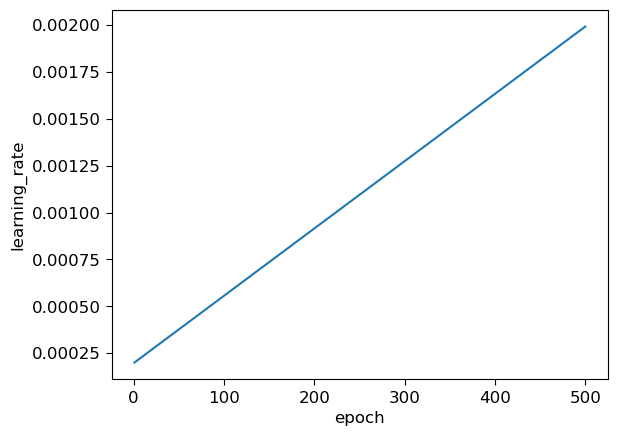

In [27]:
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

''

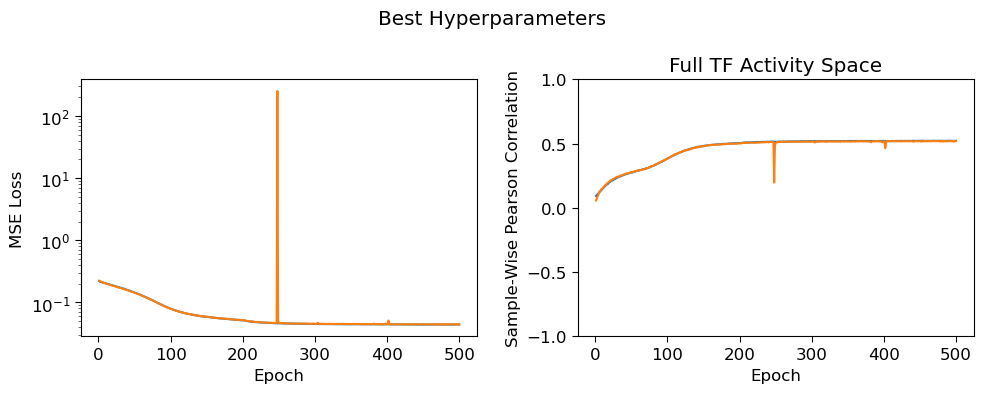

In [28]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 4))

g = sns.lineplot(data = stats_df, x = 'epoch', y = 'train_loss_mean', ax = ax[0])
g = sns.lineplot(data = stats_df, x = 'epoch', y = 'test_loss_mean', ax = ax[0])
ax[0].set_ylabel('MSE Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_yscale('log')

g = sns.lineplot(data = stats_df, x = 'epoch', y = 'train_pearson_mean', ax = ax[1])
g = sns.lineplot(data = stats_df, x = 'epoch', y = 'test_pearson_mean', ax = ax[1])
ax[1].set_title('Full TF Activity Space')
ax[1].set_ylabel('Sample-Wise Pearson Correlation')
ax[1].set_ylim([-1,1])
ax[1].set_xlabel('Epoch')

fig.suptitle('Best Hyperparameters')
fig.tight_layout()
;


Let's see what the train dataset will output:

In [29]:
# inputs
X_train = mod.df_to_tensor(trainer.X_train)
y_train = mod.df_to_tensor(trainer.y_train)
expr_train = mod.df_to_tensor(mod.expr.loc[trainer.X_train.index, :])
covariates_idx_train = mod.signaling_network.covariates_to_tensor(sample_ids = trainer.X_train.index)

# run prediction
mod.eval()
with torch.inference_mode():
    Y_hat, Y_full, biases = mod(X_in = X_train, covariates_idx = covariates_idx_train, expr = expr_train)
    bias_global, bias_mu, bias_log_sigma_squared = biases

# formatting
y_predicted = pd.DataFrame(Y_hat.cpu().detach().numpy())
y_predicted.index, y_predicted.columns = trainer.y_train.index, trainer.y_train.columns

In [52]:
pearsons = trainer.get_pearson_correlation(Y_hat, y_train, axis=1, return_mean=False)

''

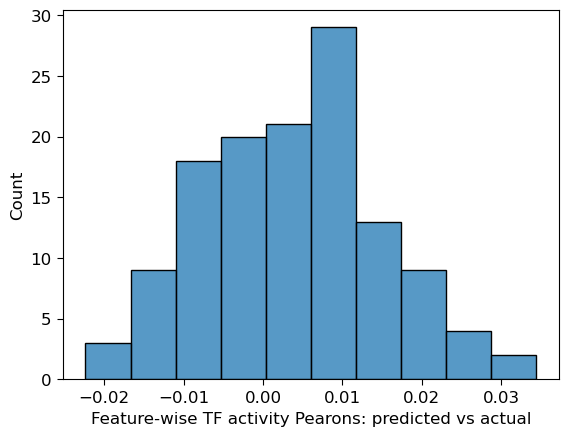

In [53]:
fig, ax = plt.subplots()
sns.histplot(pearsons, ax = ax)
ax.set_xlabel('Feature-wise TF activity Pearons: predicted vs actual')
;

In [108]:
pca_mod = subset_tf.uns['pca']['pca_mod']
rank = subset_tf.uns["pca"]['pca_rank']


md = subset_tf.obs
md['condition'] = md['celltype'].str.cat(md['Il5'].astype(str), sep='^')

X_pca = pd.DataFrame(subset_tf.obsm['X_pca'][:, :rank], 
                 index = subset_tf.obs.index, 
                columns = ['PC_{}'.format(i + 1) for i in range(rank)])
clf = NearestCentroid()
clf.fit(X_pca, md['condition'])
X_pca_centroids = pd.DataFrame(clf.centroids_, columns = clf.feature_names_in_, index = clf.classes_)

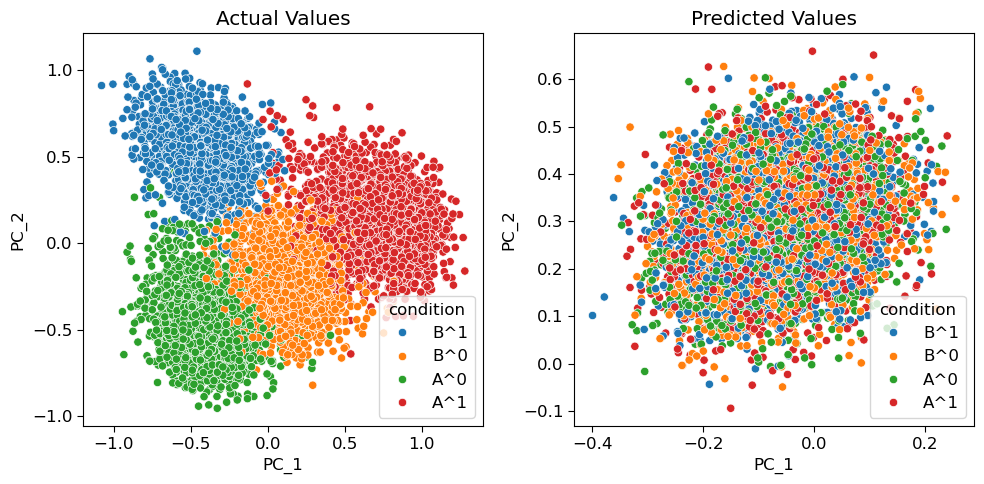

In [117]:
fig, ax = plt.subplots(figsize = (10,5), ncols = 2)


viz_df = pd.concat([X_pca.loc[trainer.y_train.index, :], pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[0])
ax[0].set_title('Actual Values')


y_pred_pca = pd.DataFrame(pca_mod.transform(y_predicted), index = y_predicted.index, 
                          columns = ['PC_{}'.format(i + 1) for i in range(pca_mod.n_components)]).iloc[:, :rank]
viz_df = pd.concat([y_pred_pca, pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[1])
ax[1].set_title('Predicted Values')

fig.tight_layout()